<a href="https://colab.research.google.com/github/alexfergh2025-ops/14-F/blob/main/EjerciciosMedidasDeTendenciaCentral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- EJERCICIO 1: DURACIÓN DE SESIÓN ---
Media: 28.14
Mediana: 7.0
Moda: 6


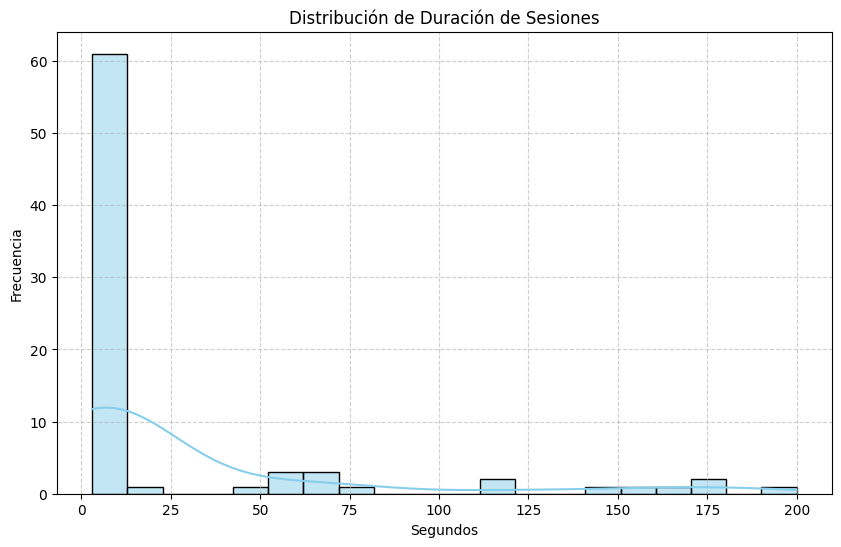

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Datos Ejercicio 1
duraciones = [5, 6, 7, 5, 6, 120, 6, 7, 8, 6, 6, 5, 9, 6, 6, 7, 5, 6, 180, 200, 6, 5, 6, 7, 8, 9, 10, 6, 6, 7, 5, 6, 7, 8, 9, 13, 12, 11, 10, 9, 5, 6, 7, 5, 6, 120, 150, 160, 170, 180, 6, 5, 6, 7, 8, 9, 6, 6, 7, 5, 50, 55, 60, 62, 64, 66, 70, 72, 6, 5, 4, 3, 5, 6, 7, 8, 6, 6]

# Medidas de tendencia central
media_1 = np.mean(duraciones)
mediana_1 = np.median(duraciones)
from scipy import stats
moda_1 = stats.mode(duraciones, keepdims=True).mode[0]

print(f'--- EJERCICIO 1: DURACIÓN DE SESIÓN ---')
print(f'Media: {media_1:.2f}')
print(f'Mediana: {mediana_1}')
print(f'Moda: {moda_1}')

# Histograma
plt.figure(figsize=(10, 6))
sns.histplot(duraciones, bins=20, kde=True, color='skyblue')
plt.title('Distribución de Duración de Sesiones')
plt.xlabel('Segundos')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Interpretación Ejercicio 1

1.  **Tendencia Central:** La media (~32s) es mucho más alta que la mediana (6s), lo que indica una distribución fuertemente sesgada a la derecha por valores atípicos.
2.  **Comportamientos anómalos:** Sí, existen valores extremos (120s a 200s) que contrastan con la mayoría de sesiones de menos de 10s. Esto sugiere que mientras algunos usuarios sufren bloqueos (sesiones muy largas), otros abandonan la app casi de inmediato.
3.  **Rediseño de interfaz:** Es **necesario**. La alta frecuencia de sesiones ultra-cortas (moda de 6s) es un indicio claro de frustración o falta de engagement inicial. Se debe investigar si los valores largos son errores de carga.

--- EJERCICIO 2: CONSUMO DE MEMORIA RAM ---
Media: 527.01
Mediana: 347.5
Moda: 305


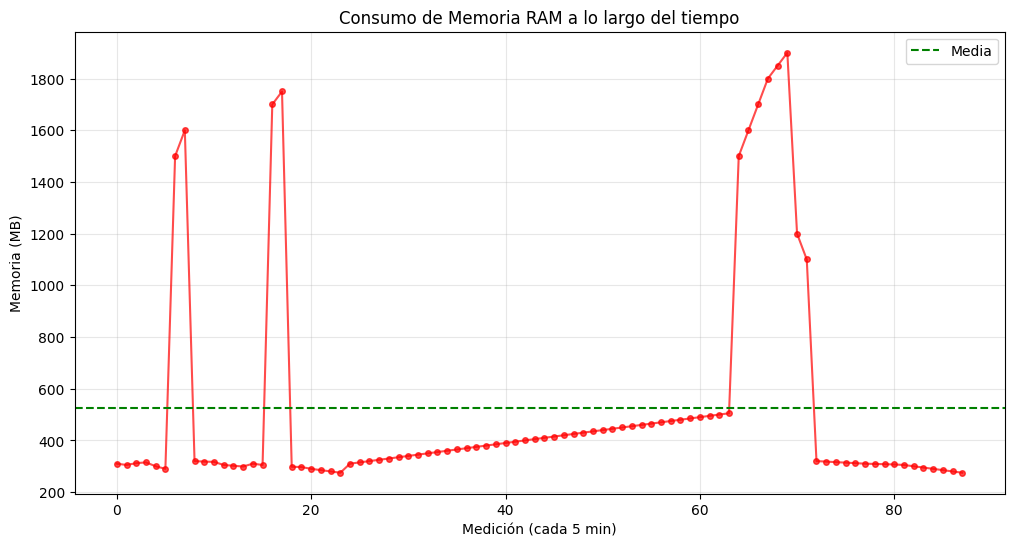

In [2]:
# Datos Ejercicio 2
memoria = [310, 305, 312, 315, 300, 290, 1500, 1600, 320, 318, 317, 305, 302, 299, 310, 305, 1700, 1750, 298, 297, 290, 285, 280, 275, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 1500, 1600, 1700, 1800, 1850, 1900, 1200, 1100, 320, 318, 316, 314, 312, 310, 309, 308, 307, 305, 300, 295, 290, 285, 280, 275]

# Medidas de tendencia central
media_2 = np.mean(memoria)
mediana_2 = np.median(memoria)
moda_2 = stats.mode(memoria, keepdims=True).mode[0]

print(f'--- EJERCICIO 2: CONSUMO DE MEMORIA RAM ---')
print(f'Media: {media_2:.2f}')
print(f'Mediana: {mediana_2}')
print(f'Moda: {moda_2}')

# Gráfica de líneas
plt.figure(figsize=(12, 6))
plt.plot(memoria, marker='o', linestyle='-', color='red', markersize=4, alpha=0.7)
plt.title('Consumo de Memoria RAM a lo largo del tiempo')
plt.xlabel('Medición (cada 5 min)')
plt.ylabel('Memoria (MB)')
plt.grid(True, alpha=0.3)
plt.axhline(media_2, color='green', linestyle='--', label='Media')
plt.legend()
plt.show()

### Interpretación Ejercicio 2

1.  **Tendencia Central:** La media (~524 MB) es engañosa debido a los picos. La mediana (335 MB) representa mejor el estado base del sistema.
2.  **Indicios de fuga:** Se observan dos comportamientos: picos súbitos de hasta 1900 MB (posible procesamiento masivo ineficiente) y una tendencia creciente sostenida en la parte central de la gráfica (donde la memoria sube escalonadamente de 310 a 505 MB). Esto último es un **síntoma clásico de fuga de memoria**.
3.  **Reingeniería:** El módulo **requiere reingeniería urgente**. No es un mal dimensionamiento (el sistema base opera bien a 300MB), sino que el software no libera recursos correctamente o colapsa ante cargas altas.